In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load cleaned data
df =pd.read_csv('uae_properties_cleaned.csv')
print("Data loaded succesfully")
print("shape:",df.shape)
df.head

Data loaded succesfully
shape: (492, 11)


<bound method NDFrame.head of                                                  title  \
0    ★ EXCLUSIVE RELEASE ★ | LUXURY 3 BED FLAT | GO...   
1    ★ BUY NOW 624,000AED ★ (20% FIRST PAYMENT + 4%...   
2    GREEN HEART OF DUBAI |URBAN DESIGN | LUXURY LI...   
3    Prime Location | Corner Spacious Unit | Bright...   
4    Very Limited | Ideal For Investment | 40% Disc...   
..                                                 ...   
487    Best Offer | Limited 3 Bed | Furnished Serviced   
488  LUXURY FLAT | GOLDEN VISA | GREAT VIEW | FLEXI...   
489                  Magnificent| Luxurious l High ROI   
490   Full Burj Khalifa  | High Floor | Confirm Seller   
491        Invest in this Modern Unit For Your Family!   

                                        displayAddress  bathrooms  bedrooms  \
0    Sobha One, Sobha Hartland, Mohammed Bin Rashid...          2         3   
1             Sobha Verde, Jumeirah Lake Towers, Dubai          2         3   
2              Park Horizon, Dubai H

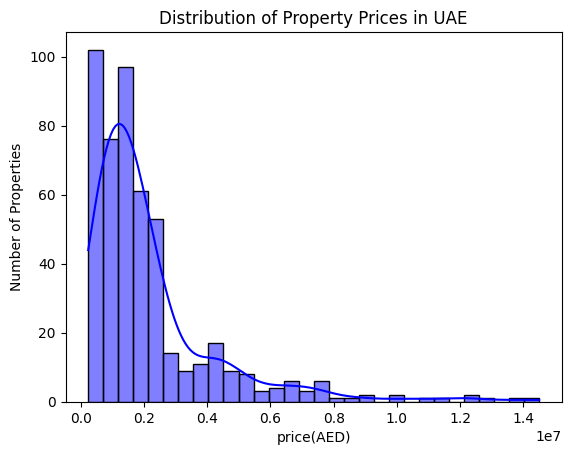

chart 1 successfully done


In [2]:
# Chart 1 Price Distribution
plt.Figure(figsize=(0,6))
sns.histplot(df['price'],bins=30,color='blue',kde=True)
plt.title('Distribution of Property Prices in UAE')
plt.xlabel('price(AED)')
plt.ylabel('Number of Properties')
plt.savefig('chart1_price_distribution.png')
plt.show()
print("chart 1 successfully done")

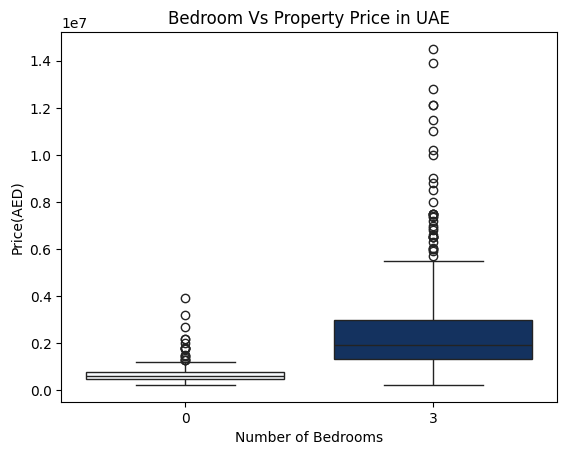

chart 2 done


In [3]:
# Chart 2 Bedroom vs Price
plt.Figure(figsize=(10,6))
sns.boxplot(x=df['bedrooms'],
            y=df['price'],
            hue=df['bedrooms'],
            palette='Blues',
            legend=False)
plt.title('Bedroom Vs Property Price in UAE')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price(AED)')
plt.savefig('chart_bedroom_vs_price.png')
plt.show()
print("chart 2 done")

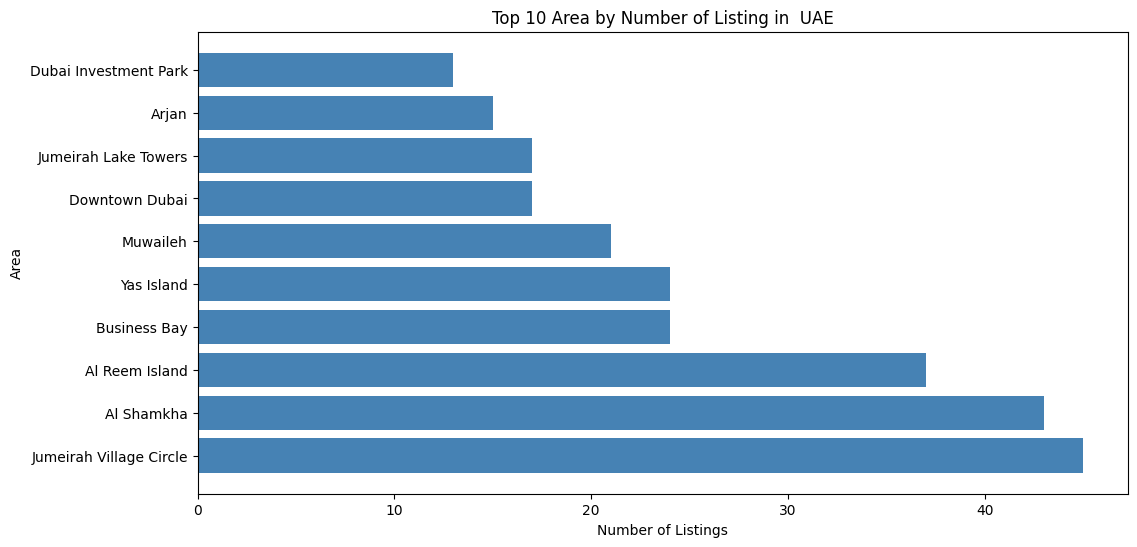

chart 3 done


In [4]:
# Chart 3 Top 10 Areas by Listings
plt.figure(figsize=(12,6))

#count top 10 areas
top_areas =df['area'].value_counts().head(10)
#plot using matplotlib directly
plt.barh(top_areas.index,
         top_areas.values,
         color='steelblue')
# Add value to each bar
for i,v in enumerate(top_areas.values):
    plt.Text(v + 0.3,i,
             str(v),
             va='center',
             fontweight='bold')
plt.title('Top 10 Area by Number of Listing in  UAE')
plt.xlabel('Number of Listings')
plt.ylabel('Area')
plt.tight_layout
plt.savefig('chart3_top10_area.png')
plt.show()
print("chart 3 done")

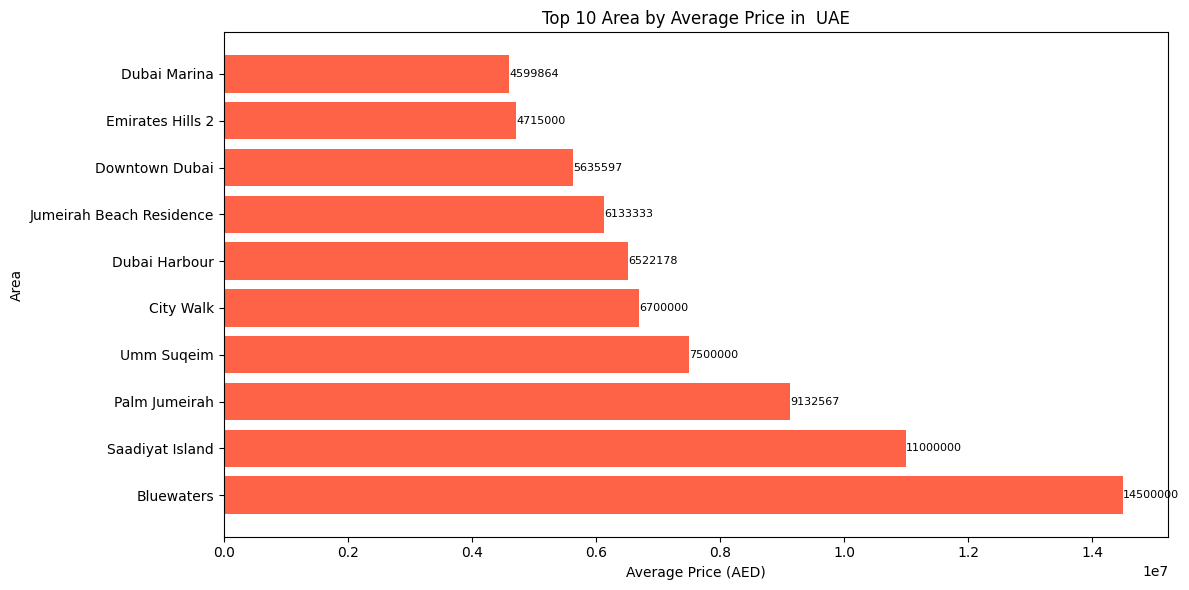

chart 4 done


In [5]:
# chart 4 Average price by Area
plt.figure(figsize=(12,6))
#calculate average price per area
avg_price =df.groupby('area')['price'].mean()
avg_price =avg_price.sort_values(ascending=False).head(10)
#plot using matplotlib directly
plt.barh(avg_price.index,
         avg_price.values,
         color='tomato')
#Add value labels on each bar
for i,v in enumerate(avg_price.values):
    plt.text(v + 1000, i, str(round(v)),
             va='center', fontsize=8,)
plt.title('Top 10 Area by Average Price in  UAE')
plt.xlabel('Average Price (AED)')
plt.ylabel('Area')
plt.tight_layout()
plt.savefig('chart4_avg_price_by_area.png')
plt.show()
print("chart 4 done")


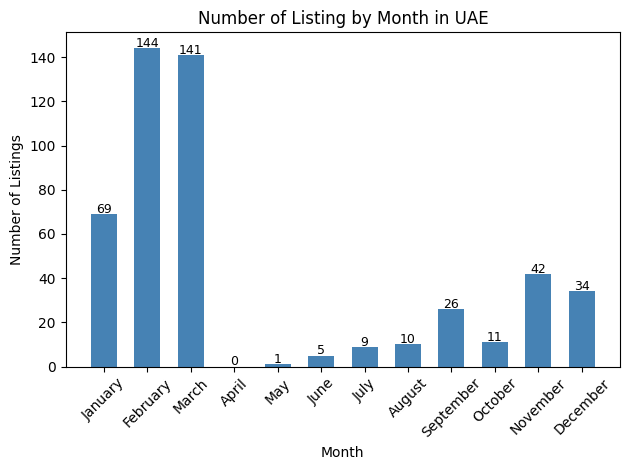

chart 5 done


In [6]:
#chart 5 Listing by Month 
plt.Figure(figsize=(12,6))
#Correct month order
month_order =['January','February','March','April','May',
              'June','July','August','September',
              'October','November','December']

#Count listings per month
monthly = df['month_name'].value_counts()
monthly =monthly.reindex(month_order,fill_value=0)

#plot 
plt.bar(range(len(monthly)),
        monthly.values,
        color='steelblue',
        width=0.6)
#add value labels on top of each bar
for i,v in enumerate(monthly.values):
    plt.text(i,v + 0.5,
             str(v),
             ha='center',
             fontsize=9,
             )
plt.title('Number of Listing by Month in UAE')
plt.xlabel('Month')
plt.ylabel('Number of Listings')
plt.xticks(range(len(month_order)),
       month_order,
       rotation=45)
plt.tight_layout()
plt.savefig('chart5_listing_by_month.png')
plt.show()
print("chart 5 done")

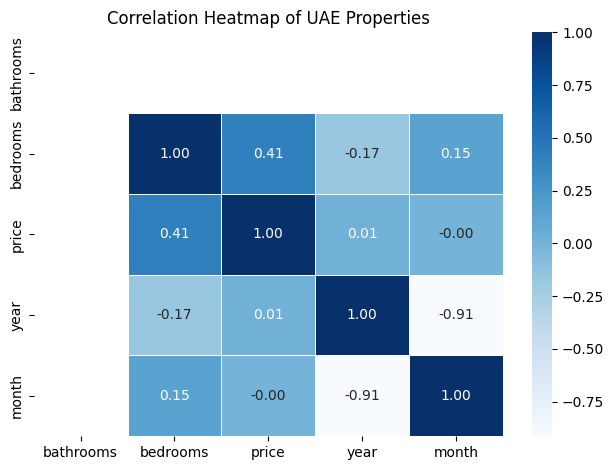

chart 6 done


In [7]:
# Chart 6 Correlation heatmap
plt.Figure(figsize=(10,6))

#select only number columns
numeric_cols = df[['bathrooms','bedrooms','price','year','month']]

#calculate correlation 
corr = numeric_cols.corr()

#plot heatmap
sns.heatmap(corr,
            annot=True,
            cmap='Blues',
            fmt='.2f',
            linewidths=0.5,
            linecolor='white')
plt.title('Correlation Heatmap of UAE Properties')
plt.tight_layout()
plt.savefig('chart6_correlation_heatmap.png')
plt.show()
print("chart 6 done")